# Análisis exploratorio de dataset de características de Spotify

**DIEGO BESADA RODRÍGUEZ**

<div>
  <img src="https://upload.wikimedia.org/wikipedia/commons/b/bd/2024_Spotify_Logo.svg"
       alt="Logo Spotify"
       width="400">
</div>

<br>

<div style="border:2px solid lightgreen; padding:10px; border-radius:5px; background-color:#ECFEEA;">
<strong>Estado:</strong> Terminado.
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ppscore as pps

In [2]:
# Existe una canción que se llama None.
# Con na_values=[] y keep_default_na=False se evita que se interprete como NaN. 
# https://www.youtube.com/watch?v=UmOEXJFi6a0 <- canción None

spotify_df = pd.read_csv("Datasets/SpotifyDataset.csv", na_values=[], keep_default_na=False)
print(spotify_df.columns.tolist())

['artist_name', 'track_id', 'track_name', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence', 'popularity']


## 1. Distribución de las características

Para comenzar el analisis, comenzaremos visualizando la distribución de cada una de las características del dataset. Las primeras distribuciones que vamos a visualizar son las variables que spotify nos da normalizadas entre 0 y 1: `danceability`, `energy`, `valence`, `acousticness`, `instrumentalness`, `liveness` y `speechiness`. 

La popularidad tambien es una variable que se encuentra normalizada entre 0 y 1, y la destacaremos con otro color (al ser la variable más importante del dataset)

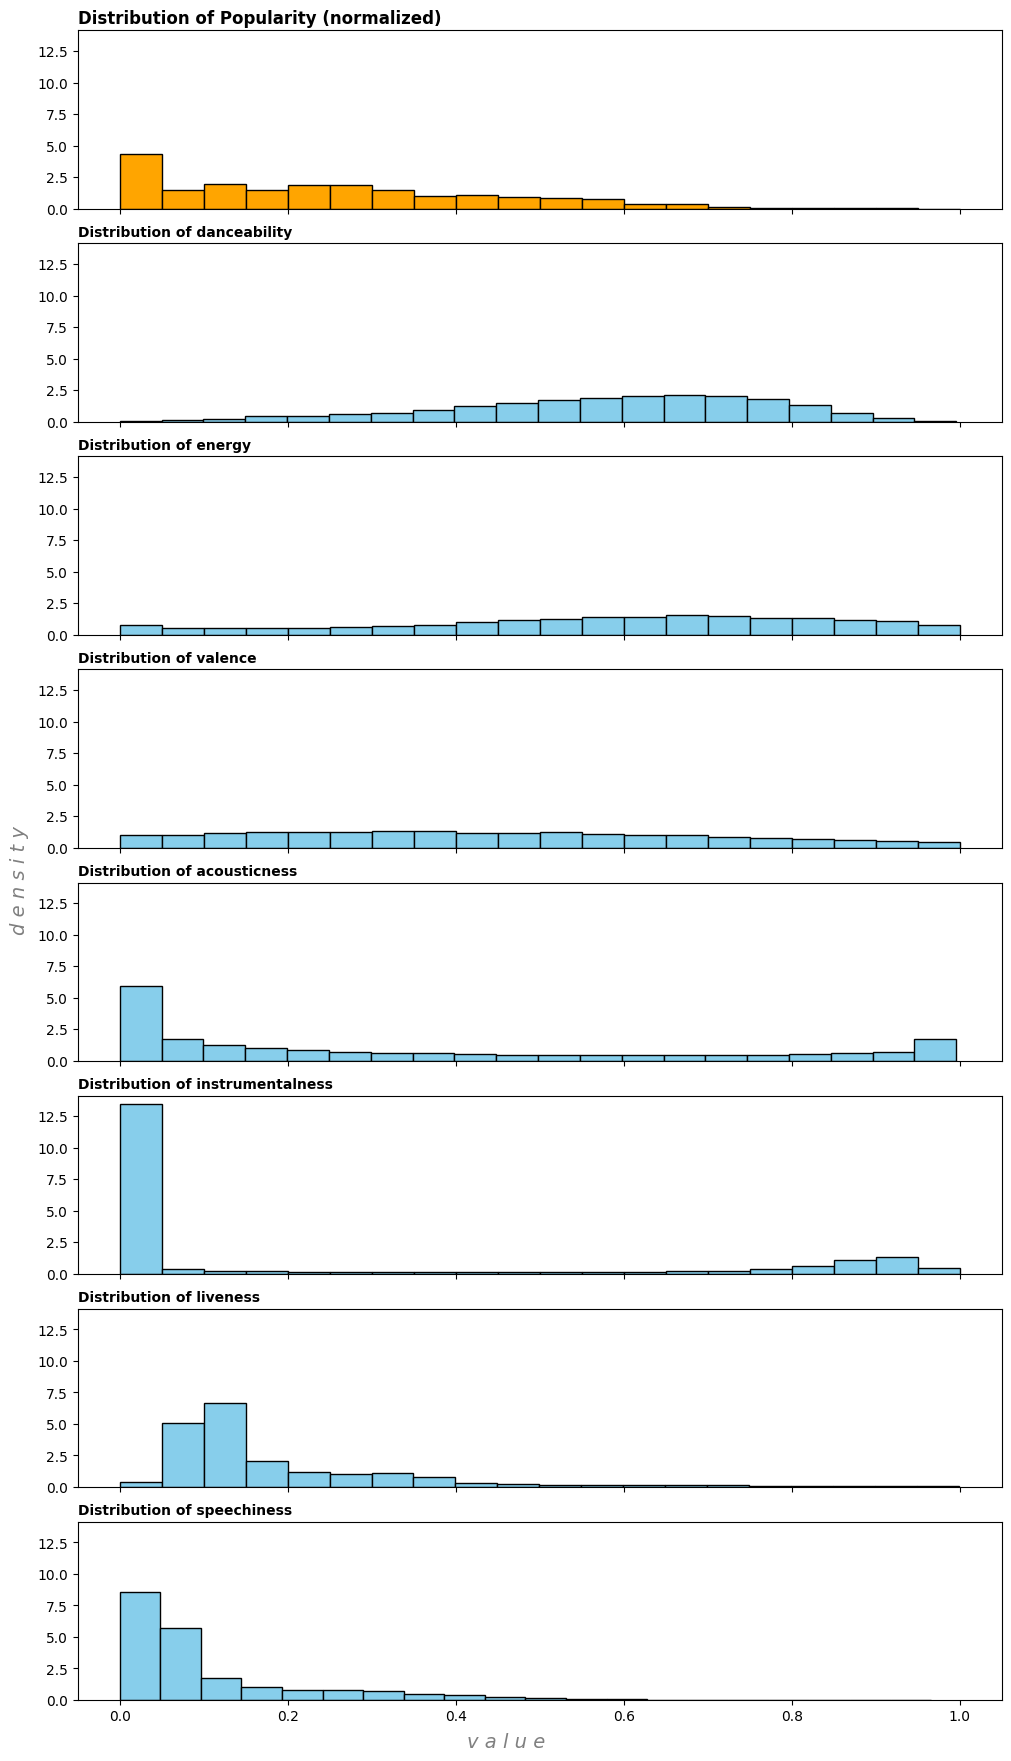

In [3]:
columns = ["danceability", "energy", "valence", "acousticness", "instrumentalness", "liveness", "speechiness"]
bins = 20
fig, axs = plt.subplots(len(columns)+1, figsize=(10, len(columns)*2.5), sharex=True, sharey=True, constrained_layout=True)
fig.supylabel("d e n s i t y", fontstyle="italic", color="gray", fontsize=14)
fig.supxlabel("v a l u e", fontstyle="italic", color="gray", fontsize=14)

axs[0].hist(spotify_df["popularity"] / 100, bins=bins, color="orange", edgecolor="black", density=True)
axs[0].set_title("Distribution of Popularity (normalized)", fontsize=12, pad=5, loc="left", fontweight="semibold")

for i, column in enumerate(columns):
    axs[i+1].hist(spotify_df[column], bins=bins, color="skyblue", edgecolor="black", density=True)
    axs[i+1].set_title(f"Distribution of {column}", fontsize=10, pad=5, loc="left", fontweight="semibold")

plt.show()

Ahora visualizaremos las distribuciones de las variables `duration_ms`, `tempo`, `loudness` y `time_signature` y `mode`, que no se encuentran normalizadas entre 0 y 1. Para estas variables, usaremos un número de bins adecuado a su rango de valores, y destacaremos la popularidad con otro color para facilitar su comparación.

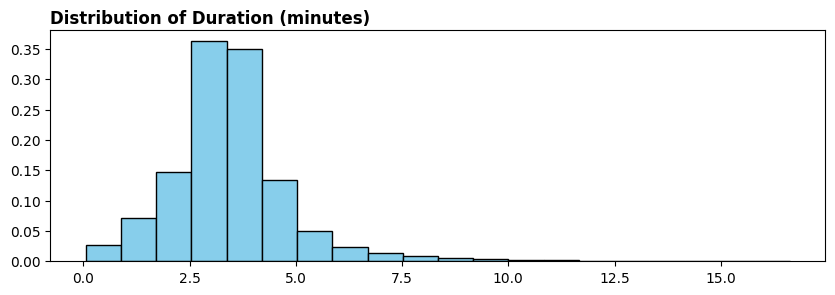

In [4]:
plt.figure(figsize=(10, 3))
plt.hist(spotify_df[spotify_df["duration_ms"]<1e6]['duration_ms'] / 60000, bins=bins, color="skyblue", edgecolor="black", density=True)
plt.title("Distribution of Duration (minutes)", pad=5, loc="left", fontweight="semibold")
plt.show()

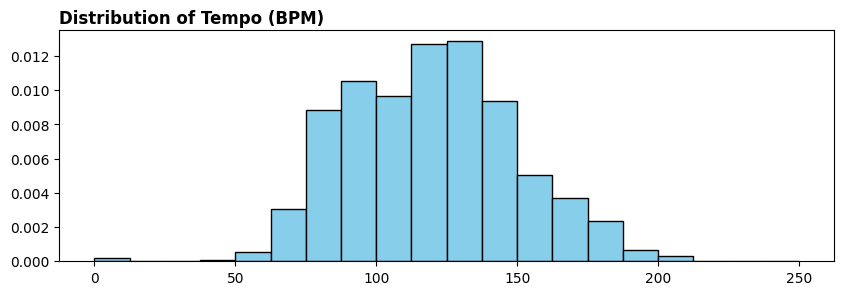

In [5]:
plt.figure(figsize=(10, 3))
plt.hist(spotify_df['tempo'], bins=bins, color="skyblue", edgecolor="black", density=True)
plt.title("Distribution of Tempo (BPM)", pad=5, loc="left", fontweight="semibold")
plt.show()

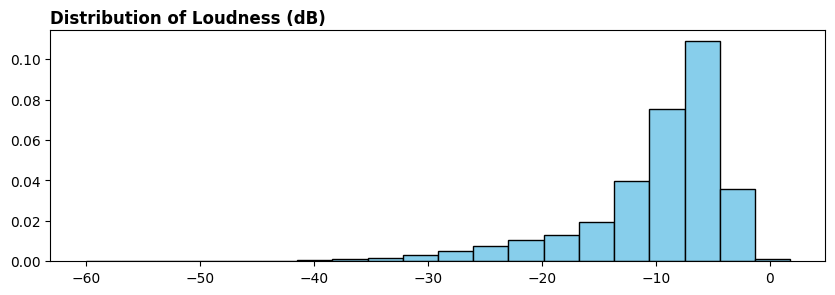

In [6]:
plt.figure(figsize=(10, 3))
plt.hist(spotify_df['loudness'], bins=bins, color="skyblue", edgecolor="black", density=True)
plt.title("Distribution of Loudness (dB)", pad=5, loc="left", fontweight="semibold")
plt.show()

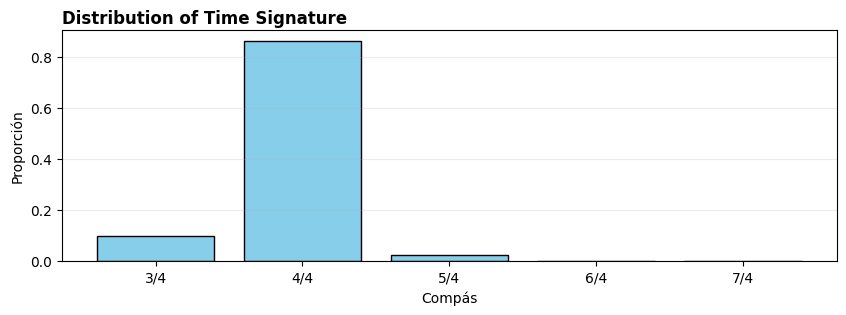

In [7]:
ts = spotify_df["time_signature"].dropna().astype(int)

if set(ts.unique()).issubset({0, 1, 2, 3, 4}):
    decode_map = {0: 3, 1: 4, 2: 5, 3: 6, 4: 7}
    ts = ts.map(decode_map)

valid_compases = [3, 4, 5, 6, 7]
counts = ts.value_counts().reindex(valid_compases, fill_value=0)

plt.figure(figsize=(10, 3))
plt.bar(
    [f"{c}/4" for c in valid_compases],
    counts / len(ts),
    color="skyblue",
    edgecolor="black"
)
plt.title("Distribution of Time Signature", pad=5, loc="left", fontweight="semibold")
plt.xlabel("Compás")
plt.ylabel("Proporción")
plt.grid(axis="y", alpha=0.25)
plt.show()

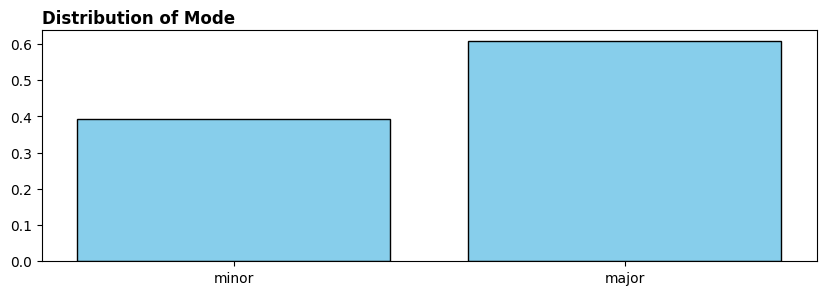

In [8]:
plt.figure(figsize=(10, 3))
plt.bar(x=[0, 1], height=spotify_df['mode'].value_counts().sort_index() / len(spotify_df), color="skyblue", edgecolor="black")
plt.title("Distribution of Mode", pad=5, loc="left", fontweight="semibold")
plt.gca().set_xticks([0, 1])
plt.gca().set_xticklabels(['minor', 'major'])
plt.show()

Por último, la función `draw_piano`, ubicada en `utilities.graphs` nos permitirá representar el histograma de las tonalidades de una manera más visual y creativa. Esta función dibuja un piano y, mediante un mapa de colores, podremos leer la cantidad de canciones que corresponden a cada nota (en este caso la tonalidad).

In [9]:
from utilities.graphs import draw_piano

key_map = {
    -1: 'Unknown',
    0: 'C', 1: 'C#',
    2: 'D', 3: 'D#',
    4: 'E',
    5: 'F', 6: 'F#',
    7: 'G', 8: 'G#',
    9: 'A', 10: 'A#',
    11: 'B'
}

cmap = plt.cm.coolwarm

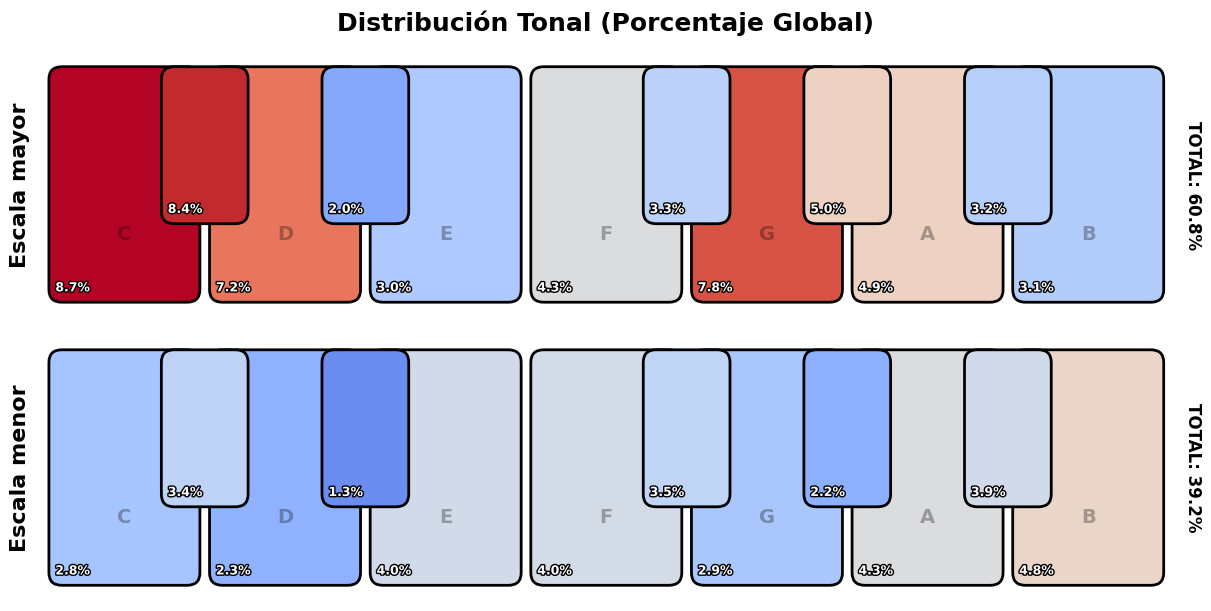

In [10]:
major_counts = (
    spotify_df[spotify_df["mode"] == 1]["key"]
    .map(key_map)
    .value_counts()
    .to_dict()
)

minor_counts = (
    spotify_df[spotify_df["mode"] == 0]["key"]
    .map(key_map)
    .value_counts()
    .to_dict()
)

# Totales
major_total = sum(major_counts.values())
minor_total = sum(minor_counts.values())
global_total = major_total + minor_total

# Máximo para normalización de color
max_value = max(
    max(major_counts.values(), default=0),
    max(minor_counts.values(), default=0)
)

# Funciones para esta visualización (porcentaje global)
norm = lambda v: v / max_value if max_value else 0
label = lambda v: f"{(v / global_total) * 100:.1f}%" if global_total else ""

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True)
fig.suptitle("Distribución Tonal (Porcentaje Global)", fontsize=18, fontweight="bold")

draw_piano(axes[0], major_counts, "Escala mayor", cmap, norm, label, annotation=f"TOTAL: {major_total/global_total:.1%}")
draw_piano(axes[1], minor_counts, "Escala menor", cmap, norm, label, annotation=f"TOTAL: {minor_total/global_total:.1%}")

plt.show()

Podemos observar que la mayoría de las canciones se encuentran en tonalidades mayores, siendo la tonalidad más común la de Do mayor (C). En cuanto a las tonalidades menores, la más frecuente es Si menor (B).

## 2. Correlación entre características

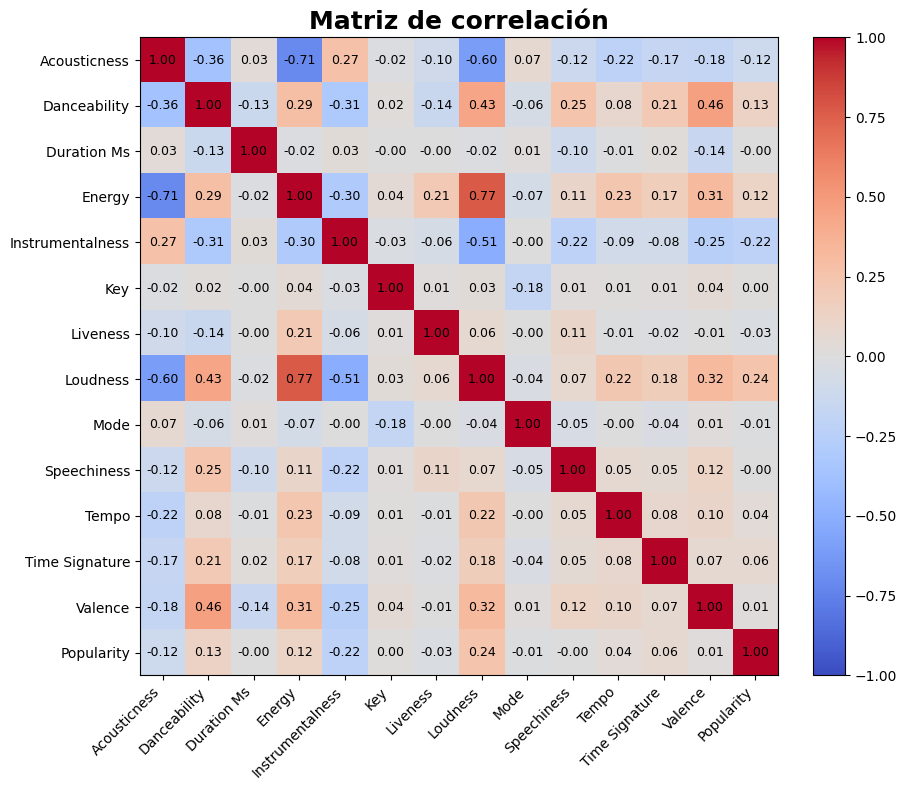

In [11]:
columns = spotify_df.select_dtypes(include="number").columns
corr = spotify_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(columns)))
ax.set_yticks(range(len(columns)))
ax.set_xticklabels([col.replace("_", " ").title() for col in columns], rotation=45, ha="right")
ax.set_yticklabels([col.replace("_", " ").title() for col in columns])
ax.set_title("Matriz de correlación", fontsize=18, fontweight="bold")

for i in range(len(columns)):
    for j in range(len(columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

A priori podemos ver que existen muy pocas correlaciones lineales fuertes entre las características del dataset, pudiendo destacar únicamente las relaciones entre `energy`, `loudness`y `acousticness`: las dos primeras son directamente relacionadas mientras que `acousticness` es inversamente relacionada con ambas. Esto tiene sentido, ya que las canciones con mayor energía y volumen suelen ser menos acústicas, mientras que las canciones más acústicas tienden a tener menor energía y volumen.

Como la correlación de Pearson solo mide relaciones lineales entre variables, es posible que existan relaciones no lineales entre las características del dataset que no sean capturadas por esta métrica. Para abordar esta limitación, utilizaremos el Predictive Power Score (PPS), una métrica que evalúa la capacidad predictiva de una variable sobre otra, independientemente de la forma de la relación entre ellas. Esto, además nos permitirá identificar qué variables tienen mayor poder predictivo sobre la popularidad de las canciones, más robusto que una simple correlación lineal.

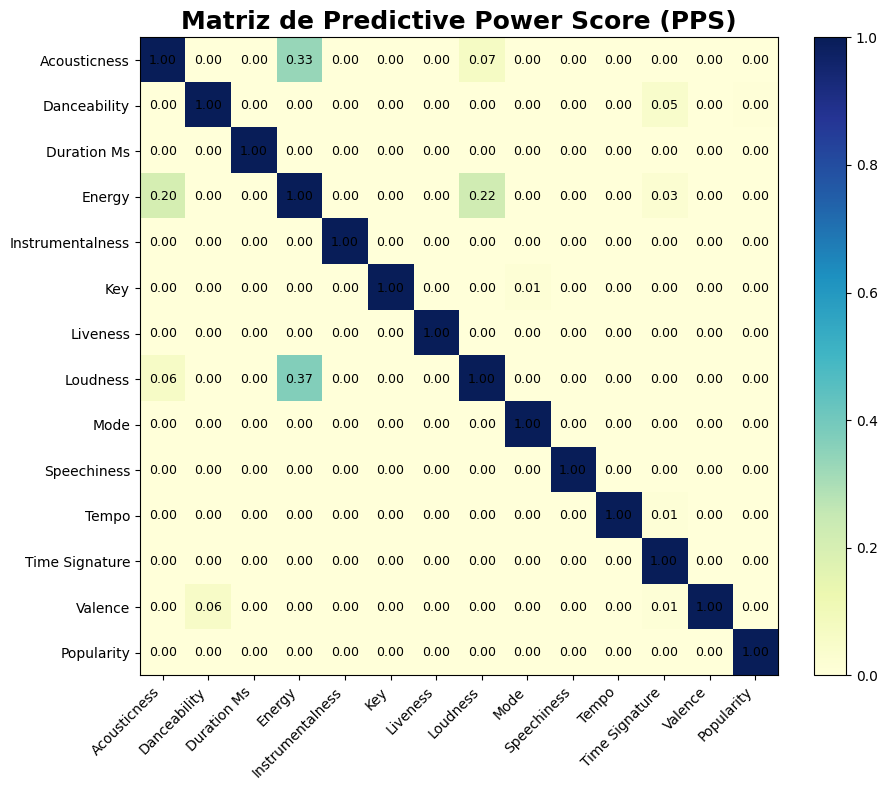

In [12]:
pps_matrix_long = pps.matrix(spotify_df[columns])[["x", "y", "ppscore"]]
pps_matrix = pps_matrix_long.pivot(index="y", columns="x", values="ppscore").loc[columns, columns]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(pps_matrix, vmin=0, vmax=1, cmap="YlGnBu")

ax.set_xticks(range(len(columns)))
ax.set_yticks(range(len(columns)))
ax.set_xticklabels([col.replace("_", " ").title() for col in columns], rotation=45, ha="right")
ax.set_yticklabels([col.replace("_", " ").title() for col in columns])
ax.set_title("Matriz de Predictive Power Score (PPS)", fontsize=18, fontweight="bold")

for i in range(len(columns)):
    for j in range(len(columns)):
        ax.text(j, i, f"{pps_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=9)

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Conclusión: no existe ningun atributo que tenga un poder predictivo sobre la popularidad de las canciones (ni al revés). Volvemos a ver que la energía, el volumen y la acústica, las características que señalabamos antes, sí tienen una relación entre ellas. `loudness` y `acousticness` predicen (moderadamente, 0.37 y 0.33) la energía (y viceversa, pero con un poder predictivo algo menor).

## 3. Análisis en profundidad por grupos de características

Para continuar con una exploración del dataset, nos centraremos de manera más detallada en los siguientes grupos de caracteristicas:

**🎼 Atributos armónicos y marco tonal**

*Describen el sistema tonal de la canción*

- `key`
- `mode`
- `valence` → a veces puede estar relacionado el modo mayor/menor con la“felicidad/ tristeza” de la canción (a pesar de que en el dataset no parece haber una relación clara entre ambas variables)

**🥁 Atributos de ritmo y métrica**

*Describen el comportamiento temporal*

- `tempo` → velocidad de la canción
- `time_signature` → compás
- `danceability` → facilidad de baile según ritmo y energía


**🔊 Intensidad y dinámica**

*Variables relacionadas con fuerza sonora*

- `energy`
- `loudness`


**🎛 Textura y timbre**

*Caracteriza el tipo de sonido*

- `acousticness` → orgánico vs electrónico
- `instrumentalness` → voz vs instrumental
- `speechiness` → rap / spoken word
- `liveness` → probabilidad (0–1) de que la pista haya sido interpretada en directo

Además, tenemos las variables `duración` y `popularidad`. Esta última la usaremos para estudiar patrones condicionales respecto a otras variables, por ejemplo, cómo cambia la popularidad según el modo, la tonalidad o el tempo.

### **🎼 Atributos armónicos y marco tonal**

Primero miraremos algunas relaciones entre estos atributos y la popularidad de las canciones, aunque ya hemos visto que no existe una relación lineal fuerte entre estas variables y la popularidad.

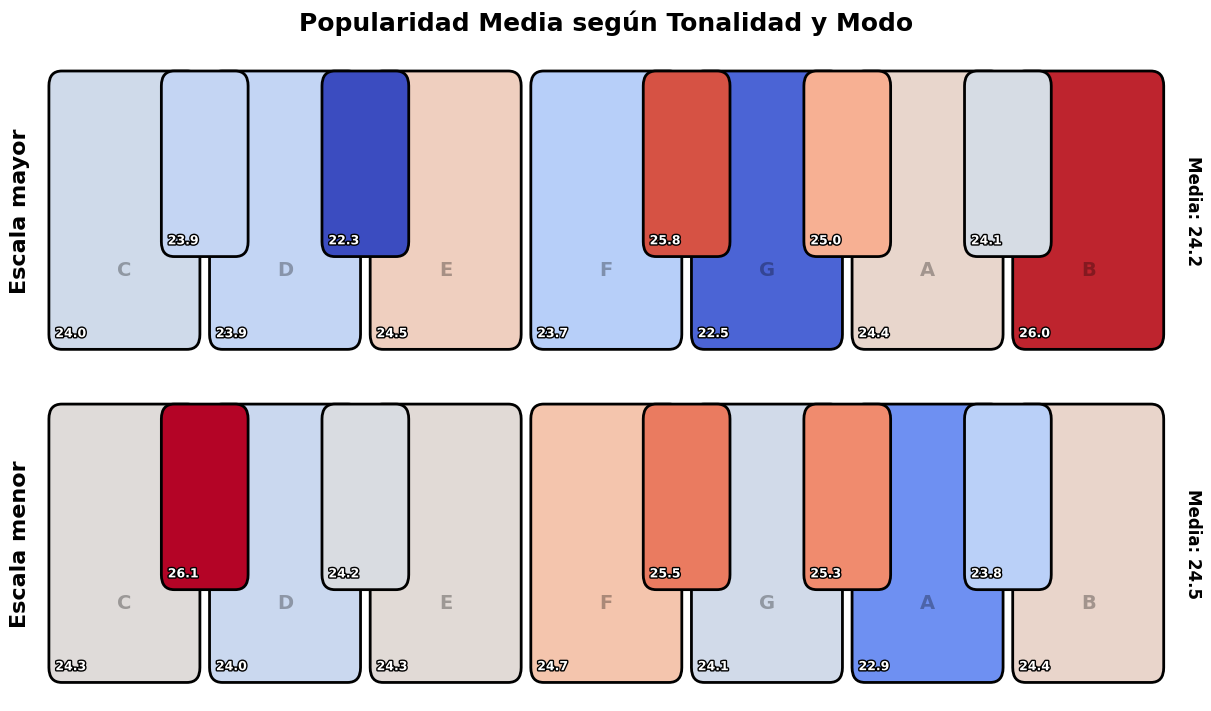

In [13]:
avg_pop_series = spotify_df.groupby(['mode', 'key'])['popularity'].mean()

major_pops = {key_map[k]: v for (m, k), v in avg_pop_series.items() if m == 1}
minor_pops = {key_map[k]: v for (m, k), v in avg_pop_series.items() if m == 0}

# Rango para normalización de color
all_values = list(major_pops.values()) + list(minor_pops.values())
min_pop, max_pop = min(all_values), max(all_values)
pop_range = max_pop - min_pop if max_pop > min_pop else 1

# Funciones para draw_piano
norm = lambda v: (v - min_pop) / pop_range
label = lambda v: f"{v:.1f}"

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
fig.suptitle("Popularidad Media según Tonalidad y Modo", fontsize=18, fontweight="bold")

draw_piano(axes[0], major_pops, "Escala mayor", cmap, norm, label, annotation=f"Media: {sum(major_pops.values())/len(major_pops):.1f}")
draw_piano(axes[1], minor_pops, "Escala menor", cmap, norm, label, annotation=f"Media: {sum(minor_pops.values())/len(minor_pops):.1f}")

plt.show()

In [14]:
from utilities.graphs import joyplot

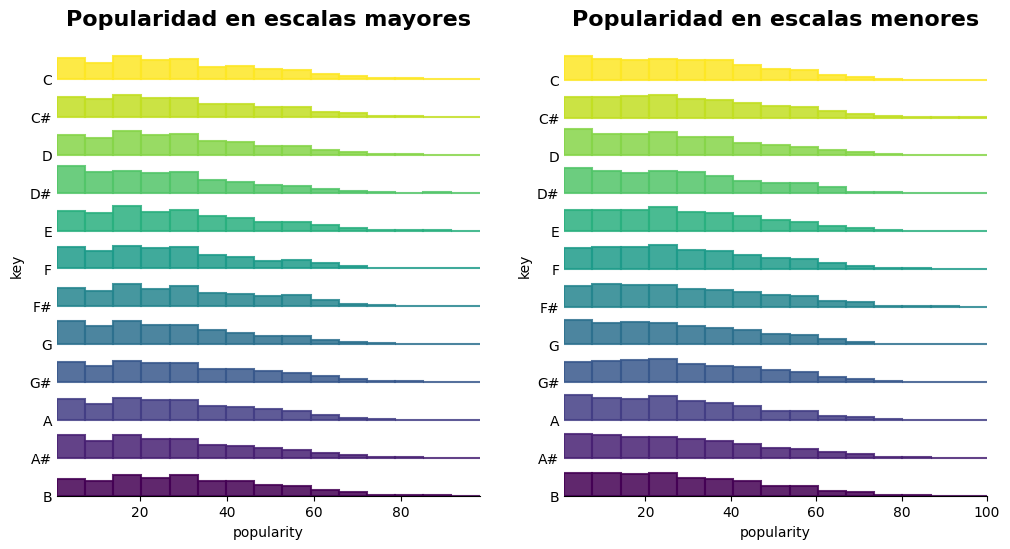

In [15]:
df = spotify_df[["key", "mode", "popularity"]][spotify_df["popularity"] > 0].copy()  # <- modificar umbral para enfocar en canciones más populares

df = df.sort_values("key", ascending=False)

df["key"] = df["key"].map(key_map)
df["mode"] = df["mode"].map({0: "Minor", 1: "Major"})

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, mode in zip(axes, ["Major", "Minor"]):
    joyplot(
        ax,
        df[df["mode"] == mode],
        group_col="key",
        value_col="popularity",
        offset=1.3,
        bins=15,
    )
    ax.set_title(f"Popularidad en escalas {'mayores' if mode == 'Major' else 'menores'}", fontsize=16, fontweight="bold")

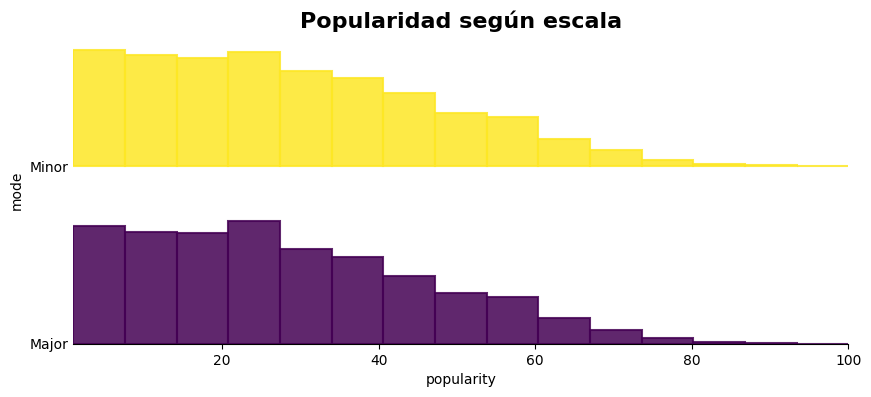

In [16]:
df = spotify_df[["mode", "popularity"]][spotify_df["popularity"] > 0] # <- modificar umbral para enfocar en canciones más populares
df['mode'] = df['mode'].map({0: 'Minor', 1: 'Major'})

fig, ax = plt.subplots(figsize=(10, 4))

joyplot(
    ax,
    df,
    group_col="mode",
    value_col="popularity",
    offset=1.3,
    bins=15,
)
plt.title("Popularidad según escala", fontsize=16, fontweight="bold")
plt.show()

¿Las escalas mayores tienden a valores de valencia algo más altos? No en nuestro dataset:

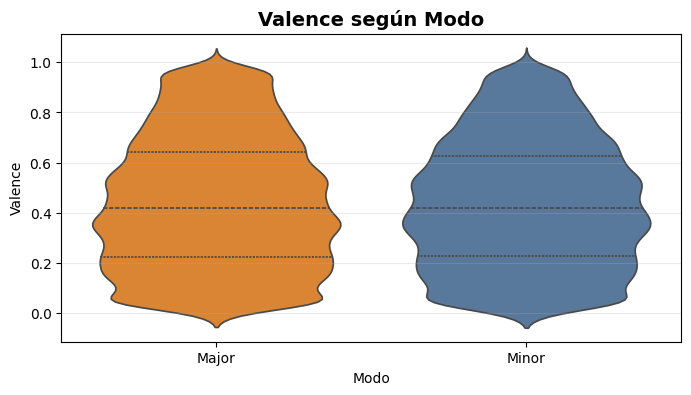

In [17]:
mode_valence_df = spotify_df[["mode", "valence"]].dropna().copy()
mode_valence_df["mode_label"] = mode_valence_df["mode"].map({0: "Minor", 1: "Major"})

plt.figure(figsize=(8, 4))
sns.violinplot(
    data=mode_valence_df,
    x="mode_label",
    y="valence",
    hue="mode_label",
    inner="quartile",
    palette={"Minor": "#4C78A8", "Major": "#F58518"},
    legend=False,
)
plt.title("Valence según Modo", fontsize=14, fontweight="bold")
plt.xlabel("Modo")
plt.ylabel("Valence")
plt.grid(axis="y", alpha=0.25)
plt.show()

¿cómo se reparte el modo mayor/menor dentro de cada tonalidad? ¿existen tonalidades que tiendan a ser más mayores o menores?

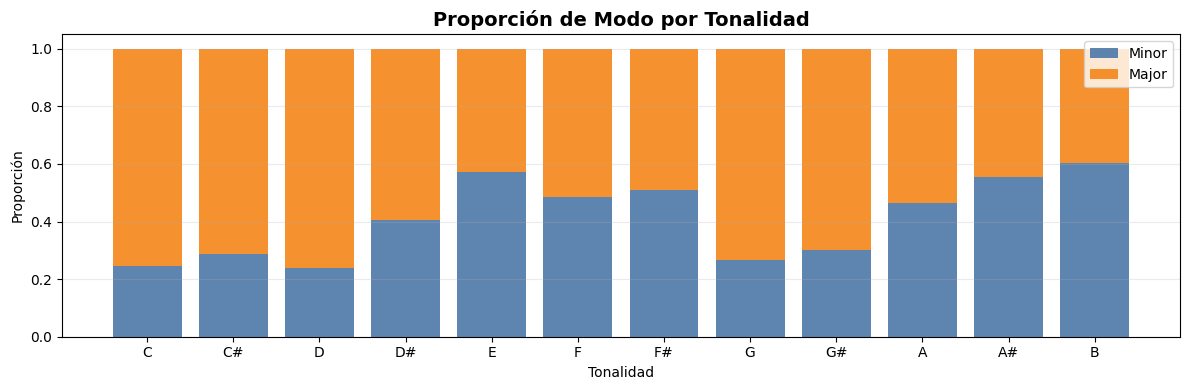

In [18]:
harmonic_count_df = spotify_df[["key", "mode"]].copy()
harmonic_count_df = harmonic_count_df[harmonic_count_df["key"].between(0, 11)]
harmonic_count_df["mode_label"] = harmonic_count_df["mode"].map({0: "Minor", 1: "Major"})
harmonic_count_df["key_label"] = harmonic_count_df["key"].map(key_map)

key_mode_counts = (
    harmonic_count_df
    .groupby(["key_label", "mode_label"])
    .size()
    .unstack(fill_value=0)
    .reindex([key_map[k] for k in range(12)])
)

key_mode_props = key_mode_counts.div(key_mode_counts.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(key_mode_props.index, key_mode_props["Minor"], label="Minor", color="#4C78A8", alpha=0.9)
ax.bar(
    key_mode_props.index,
    key_mode_props["Major"],
    bottom=key_mode_props["Minor"],
    label="Major",
    color="#F58518",
    alpha=0.9,
)
ax.set_title("Proporción de Modo por Tonalidad", fontsize=14, fontweight="bold")
ax.set_ylabel("Proporción")
ax.set_xlabel("Tonalidad")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

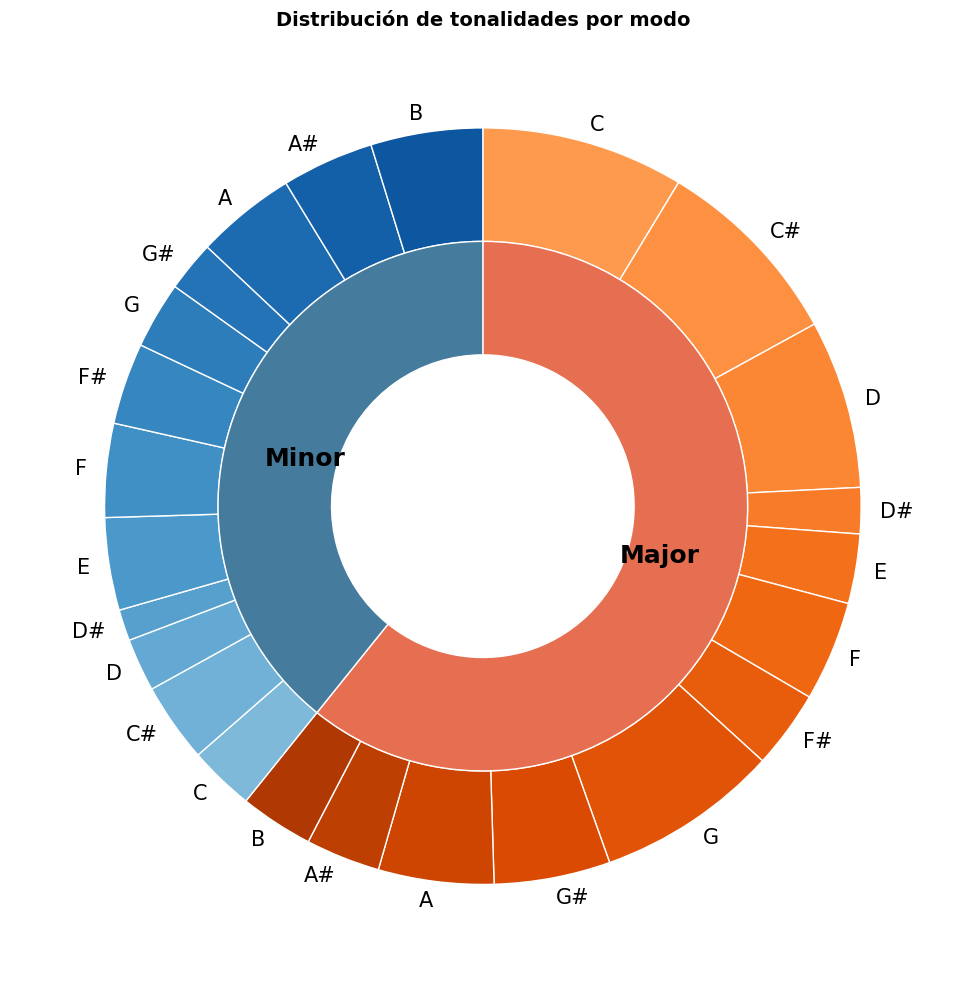

In [19]:
plot_df = harmonic_count_df.groupby(["mode_label", "key_label"]).size().reset_index(name="count")

# Orden musical de tonalidades
key_order = [key_map[k] for k in range(12)]
mode_order = ["Major", "Minor"]

plot_df["mode_label"] = pd.Categorical(plot_df["mode_label"], categories=mode_order, ordered=True)
plot_df["key_label"] = pd.Categorical(plot_df["key_label"], categories=key_order, ordered=True)
plot_df = plot_df.sort_values(["mode_label", "key_label"])

# Anillo externo
outer_labels = plot_df["key_label"].astype(str).tolist()
outer_sizes = plot_df["count"].to_numpy()

# Colores más agradables y coherentes por modo
major_palette = plt.cm.Oranges(np.linspace(0.45, 0.85, 12))
minor_palette = plt.cm.Blues(np.linspace(0.45, 0.85, 12))
outer_colors = np.vstack([major_palette, minor_palette])

# Anillo interno
inner_df = plot_df.groupby("mode_label", as_index=False)["count"].sum()
inner_labels = inner_df["mode_label"].tolist()
inner_sizes = inner_df["count"].to_numpy()
inner_colors = ["#E76F51", "#457B9D"]  # Major / Minor

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(aspect="equal"))

ax.pie(
    outer_sizes,
    radius=1.0,
    labels=outer_labels,
    labeldistance=1.05,
    colors=outer_colors,
    wedgeprops=dict(width=0.30, edgecolor="white"),
    startangle=90,
    counterclock=False,
    textprops={"fontsize": 15}
)

ax.pie(
    inner_sizes,
    radius=0.70,
    labels=inner_labels,
    labeldistance=0.55,
    colors=inner_colors,
    wedgeprops=dict(width=0.30, edgecolor="white"),
    startangle=90,
    counterclock=False,
    textprops={"fontsize": 18, "fontweight": "bold", "color": "black"}
)

ax.set_title("Distribución de tonalidades por modo", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### **🥁 Atributos de ritmo y métrica**

Nos adrentaamos en variables que tienen que ver con el ritmo y la métrica de las canciones, como el tempo, el compás y, de manera derivada, lo bailable que es, la energía, ...

In [20]:
rhythm_df = spotify_df[["tempo", "time_signature", "danceability", "energy", "valence", "popularity", "acousticness"]].dropna().copy()
rhythm_df = rhythm_df[(rhythm_df["tempo"] >= 40) & (rhythm_df["tempo"] <= 220)]
rhythm_df["time_signature"] = rhythm_df["time_signature"].astype(int)

Hemos afirmado que la danceability, energy, valence... son características que pueden estar relacionadas con el tempo de las canciones. ¿Cómo? Vamos a ver cómo varían a lo largo de los tramos de tempo.

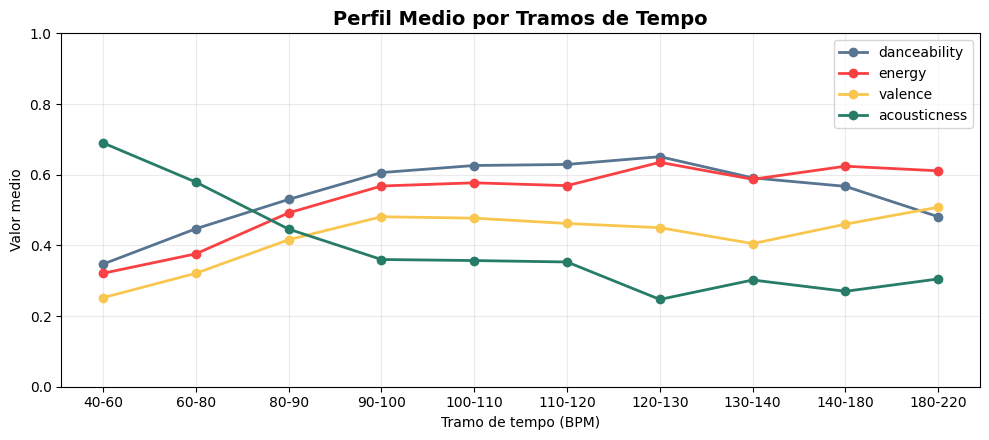

In [21]:
rhythm_df["tempo_bin"] = pd.cut(
    rhythm_df["tempo"],
    bins=[40, 60, 80, 90, 100, 110, 120, 130, 140, 180, 220],
    labels=["40-60", "60-80", "80-90", "90-100", "100-110", "110-120", "120-130", "130-140", "140-180", "180-220"],
    include_lowest=True
)

tempo_summary = (
    rhythm_df
    .groupby("tempo_bin")[["danceability", "energy", "valence", "acousticness"]]
    .mean()
    .round(3)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
for col, color in zip(["danceability", "energy", "valence", "acousticness"], ["#577590", "#F94144", "#F9C74F", "#277C68"]):
    ax.plot(tempo_summary.index.astype(str), tempo_summary[col], marker="o", linewidth=2, color=color, label=col)

ax.set_title("Perfil Medio por Tramos de Tempo", fontsize=14, fontweight="bold")
ax.set_xlabel("Tramo de tempo (BPM)")
ax.set_ylabel("Valor medio")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

¿Si hablamos de las canciones más bailables, qué tempo suelen tener? ¿y las menos bailable? Analicemos también esto mismo con la energía, la valencia, la acústica... en relacion al tempo.

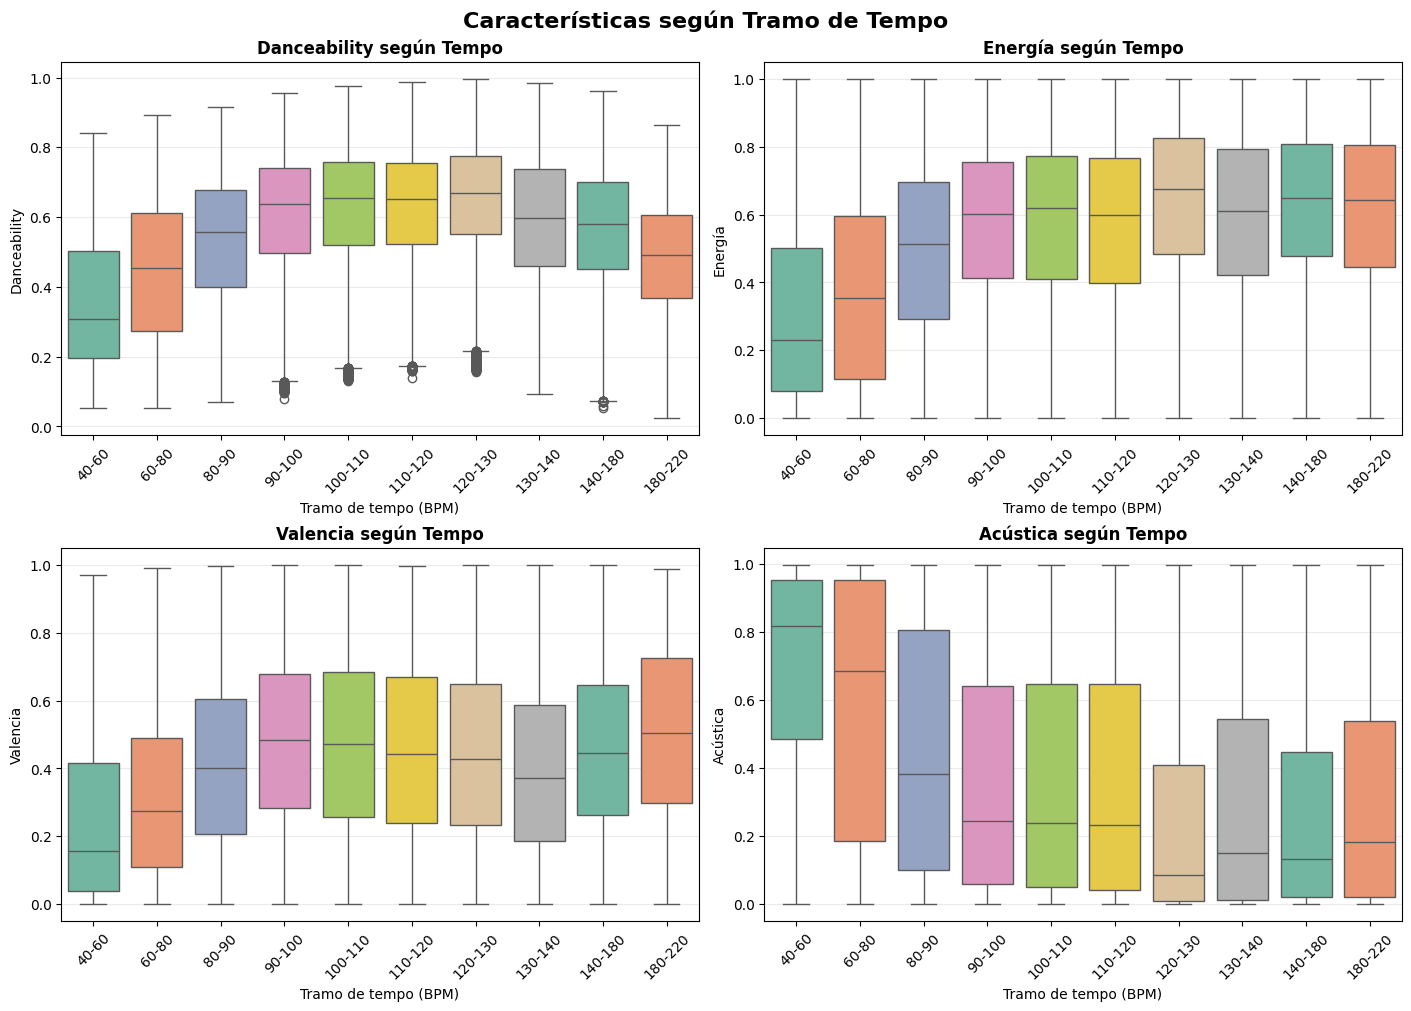

In [22]:
tempo_characteristics_df = rhythm_df[["tempo_bin", "danceability", "energy", "valence", "acousticness"]].copy()

# Crear figura con 4 subplots (uno para cada característica)
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
fig.suptitle("Características según Tramo de Tempo", fontsize=16, fontweight="bold")

# Danceability vs Tempo
sns.boxplot(
    data=tempo_characteristics_df,
    x="tempo_bin",
    y="danceability",
    ax=axes[0, 0],
    palette="Set2",
    hue="tempo_bin",
    dodge=False,
)
axes[0, 0].set_title("Danceability según Tempo", fontweight="bold")
axes[0, 0].set_xlabel("Tramo de tempo (BPM)")
axes[0, 0].set_ylabel("Danceability")
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis="y", alpha=0.25)

# Energy vs Tempo
sns.boxplot(
    data=tempo_characteristics_df,
    x="tempo_bin",
    y="energy",
    ax=axes[0, 1],
    palette="Set2",
    hue="tempo_bin",
    dodge=False,
)
axes[0, 1].set_title("Energía según Tempo", fontweight="bold")
axes[0, 1].set_xlabel("Tramo de tempo (BPM)")
axes[0, 1].set_ylabel("Energía")
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis="y", alpha=0.25)

# Valence vs Tempo
sns.boxplot(
    data=tempo_characteristics_df,
    x="tempo_bin",
    y="valence",
    ax=axes[1, 0],
    palette="Set2",
    hue="tempo_bin",
    dodge=False,
)
axes[1, 0].set_title("Valencia según Tempo", fontweight="bold")
axes[1, 0].set_xlabel("Tramo de tempo (BPM)")
axes[1, 0].set_ylabel("Valencia")
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis="y", alpha=0.25)

# Acousticness vs Tempo
sns.boxplot(
    data=tempo_characteristics_df,
    x="tempo_bin",
    y="acousticness",
    ax=axes[1, 1],
    palette="Set2",
    hue="tempo_bin",
    dodge=False,
)
axes[1, 1].set_title("Acústica según Tempo", fontweight="bold")
axes[1, 1].set_xlabel("Tramo de tempo (BPM)")
axes[1, 1].set_ylabel("Acústica")
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis="y", alpha=0.25)

plt.show()

¿Cómo cambia la bailabilidad media cuando combinamos dos factores a la vez: el tempo y el compás?

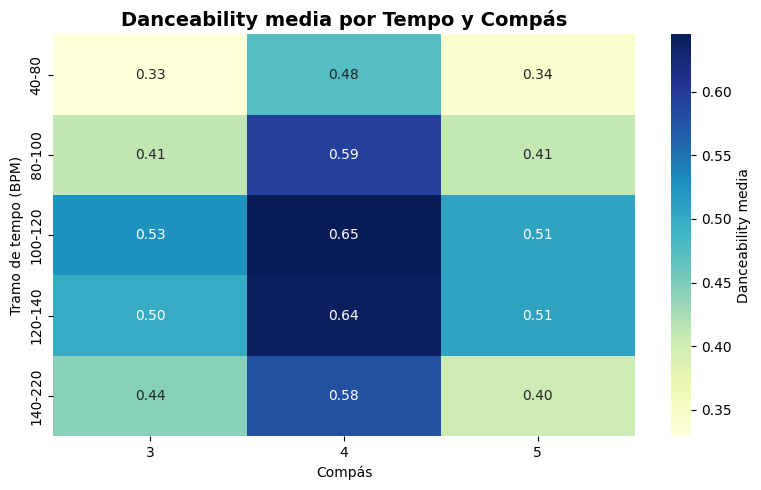

In [23]:
tempo_compas_grid = rhythm_df[rhythm_df["time_signature"].isin([3, 4, 5, 6, 7])].copy()
tempo_compas_grid["tempo_bin"] = pd.cut(
    tempo_compas_grid["tempo"],
    bins=[40, 80, 100, 120, 140, 220],
    labels=["40-80", "80-100", "100-120", "120-140", "140-220"],
    include_lowest=True
)

heat_df = (
    tempo_compas_grid
    .groupby(["tempo_bin", "time_signature"])["danceability"]
    .mean()
    .unstack()
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heat_df,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={"label": "Danceability media"},
    ax=ax
)
ax.set_title("Danceability media por Tempo y Compás", fontsize=14, fontweight="bold")
ax.set_xlabel("Compás")
ax.set_ylabel("Tramo de tempo (BPM)")
plt.tight_layout()
plt.show()

### **🔊 Intensidad y dinámica**

¿Cómo de fuerte es la relación entre energía y volumen? ¿en qué tramos de tempo se concentra la mayor intensidad sonora?

In [24]:
intensity_df = spotify_df[["tempo", "energy", "loudness", "popularity"]].dropna().copy()
intensity_df = intensity_df[(intensity_df["tempo"] >= 40) & (intensity_df["tempo"] <= 220)]

intensity_df["tempo_bin"] = pd.cut(
    intensity_df["tempo"],
    bins=[40, 60, 80, 90, 100, 110, 120, 130, 140, 180, 220],
    labels=["40-60", "60-80", "80-90", "90-100", "100-110", "110-120", "120-130", "130-140", "140-180", "180-220"],
    include_lowest=True
)

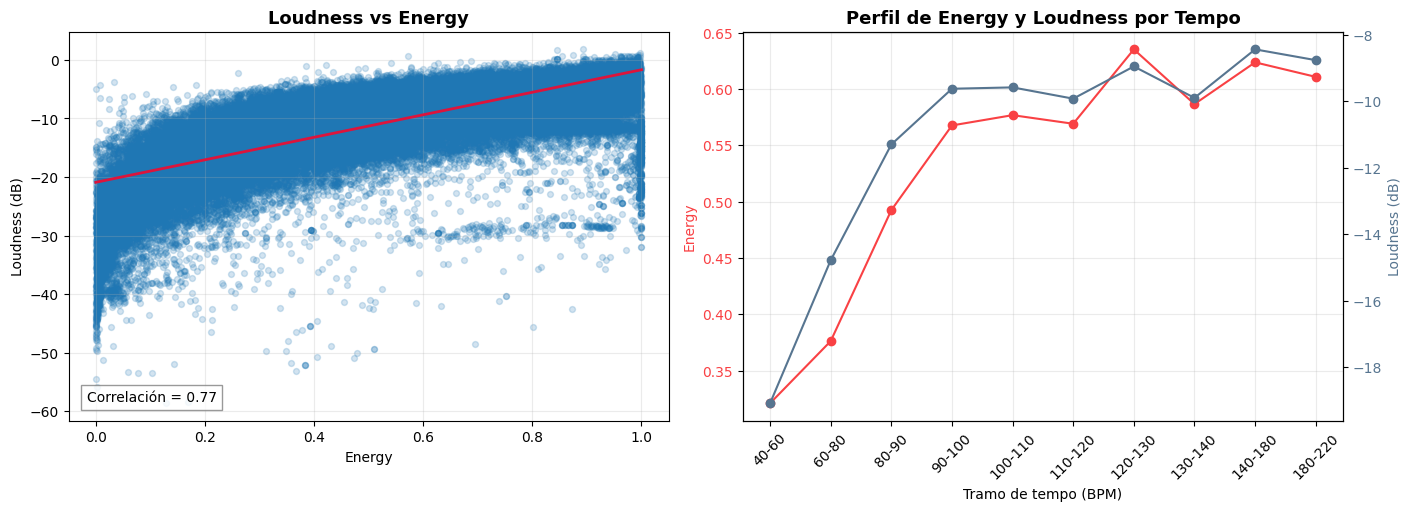

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

sns.regplot(
    data=intensity_df,
    x="energy",
    y="loudness",
    scatter_kws={"alpha": 0.2, "s": 18},
    line_kws={"color": "crimson", "lw": 2},
    ax=axes[0]
)
axes[0].set_title("Loudness vs Energy", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Energy")
axes[0].set_ylabel("Loudness (dB)")
axes[0].grid(alpha=0.25)

corr_el = intensity_df[["energy", "loudness"]].corr().iloc[0, 1]
axes[0].text(
    0.03,
    0.05,
    f"Correlación = {corr_el:.2f}",
    transform=axes[0].transAxes,
    bbox={"facecolor": "white", "alpha": 0.8, "edgecolor": "gray"}
)

tempo_intensity = (
    intensity_df
    .groupby("tempo_bin")[["energy", "loudness"]]
    .mean()
    .reset_index()
)

axes[1].plot(tempo_intensity["tempo_bin"].astype(str), tempo_intensity["energy"], marker="o", color="#F94144", label="energy")
axes[1].set_ylabel("Energy", color="#F94144")
axes[1].tick_params(axis="y", labelcolor="#F94144")
axes[1].set_xlabel("Tramo de tempo (BPM)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.25)

ax2 = axes[1].twinx()
ax2.plot(tempo_intensity["tempo_bin"].astype(str), tempo_intensity["loudness"], marker="o", color="#577590", label="loudness")
ax2.set_ylabel("Loudness (dB)", color="#577590")
ax2.tick_params(axis="y", labelcolor="#577590")

axes[1].set_title("Perfil de Energy y Loudness por Tempo", fontsize=13, fontweight="bold")

plt.show()

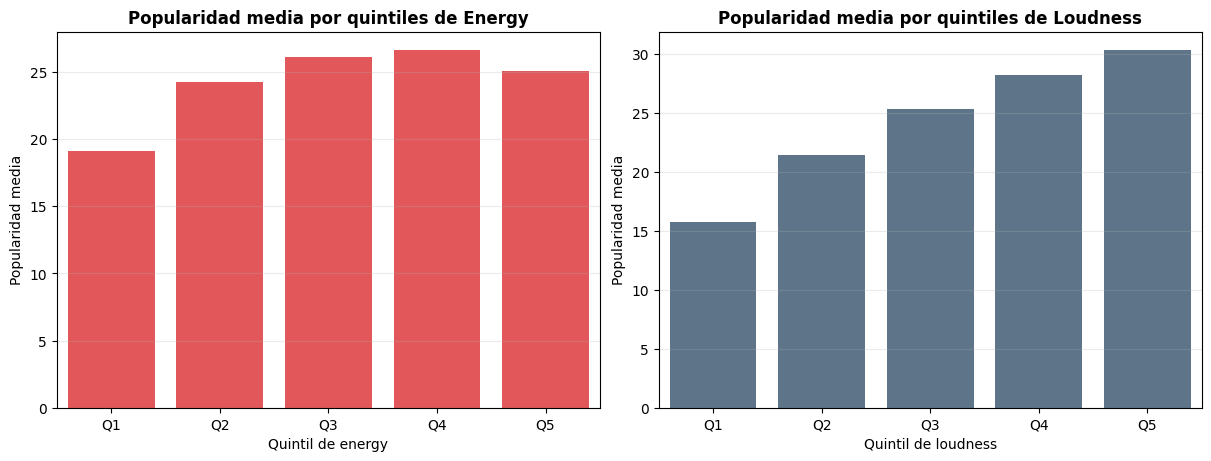

In [26]:
intensity_pop_df = intensity_df.copy()
intensity_pop_df["energy_q"] = pd.qcut(intensity_pop_df["energy"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop")
intensity_pop_df["loudness_q"] = pd.qcut(intensity_pop_df["loudness"], q=5, labels=["Q1", "Q2", "Q3", "Q4", "Q5"], duplicates="drop")

energy_pop = intensity_pop_df.groupby("energy_q")["popularity"].mean().reset_index()
loudness_pop = intensity_pop_df.groupby("loudness_q")["popularity"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

sns.barplot(data=energy_pop, x="energy_q", y="popularity", color="#F94144", ax=axes[0])
axes[0].set_title("Popularidad media por quintiles de Energy", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Quintil de energy")
axes[0].set_ylabel("Popularidad media")
axes[0].grid(axis="y", alpha=0.25)

sns.barplot(data=loudness_pop, x="loudness_q", y="popularity", color="#577590", ax=axes[1])
axes[1].set_title("Popularidad media por quintiles de Loudness", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Quintil de loudness")
axes[1].set_ylabel("Popularidad media")
axes[1].grid(axis="y", alpha=0.25)

plt.show()

¿La intensidad cambia según el compás? ¿y cómo se comporta la popularidad cuando combinamos energía y volumen al mismo tiempo?

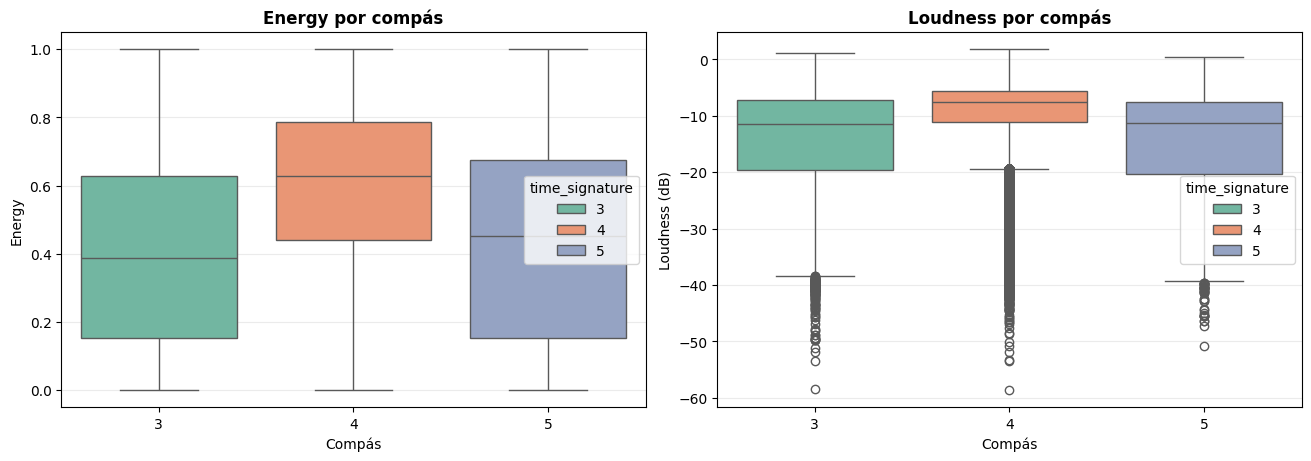

In [27]:
intensity_ts_df = spotify_df[["time_signature", "energy", "loudness"]].dropna().copy()
intensity_ts_df["time_signature"] = intensity_ts_df["time_signature"].astype(int)

if set(intensity_ts_df["time_signature"].unique()).issubset({0, 1, 2, 3, 4}):
    intensity_ts_df["time_signature"] = intensity_ts_df["time_signature"].map({0: 3, 1: 4, 2: 5, 3: 6, 4: 7})

intensity_ts_df = intensity_ts_df[intensity_ts_df["time_signature"].isin([3, 4, 5, 6, 7])]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

sns.boxplot(data=intensity_ts_df, x="time_signature", y="energy", hue="time_signature", dodge=False, palette="Set2", ax=axes[0])
axes[0].set_title("Energy por compás", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Compás")
axes[0].set_ylabel("Energy")
axes[0].grid(axis="y", alpha=0.25)

sns.boxplot(data=intensity_ts_df, x="time_signature", y="loudness", hue="time_signature", dodge=False, palette="Set2", ax=axes[1])
axes[1].set_title("Loudness por compás", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Compás")
axes[1].set_ylabel("Loudness (dB)")
axes[1].grid(axis="y", alpha=0.25)

plt.show()

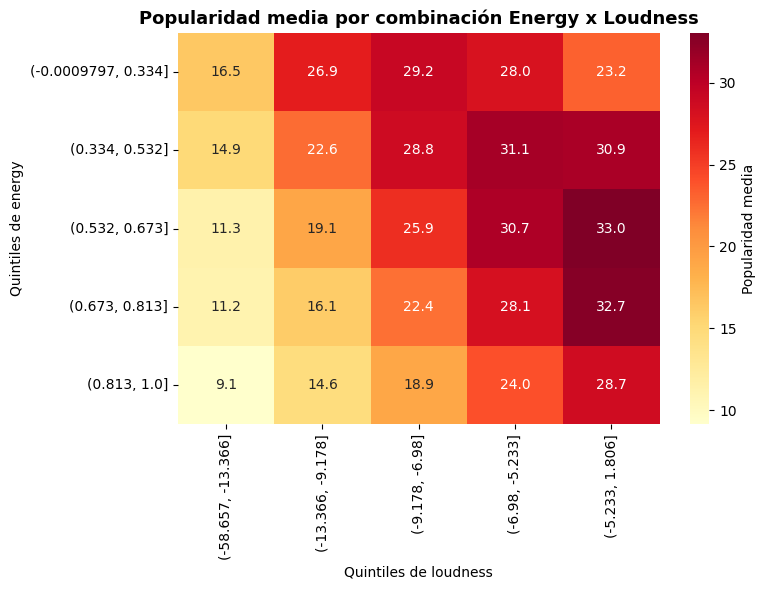

In [28]:
intensity_interaction_df = intensity_df[["energy", "loudness", "popularity"]].dropna().copy()
intensity_interaction_df["energy_bin"] = pd.qcut(intensity_interaction_df["energy"], q=5, duplicates="drop")
intensity_interaction_df["loudness_bin"] = pd.qcut(intensity_interaction_df["loudness"], q=5, duplicates="drop")

interaction_pop = (
    intensity_interaction_df
    .groupby(["energy_bin", "loudness_bin"], observed=False)["popularity"]
    .mean()
    .unstack()
)

plt.figure(figsize=(8, 6))
sns.heatmap(interaction_pop, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "Popularidad media"})
plt.title("Popularidad media por combinación Energy x Loudness", fontsize=13, fontweight="bold")
plt.xlabel("Quintiles de loudness")
plt.ylabel("Quintiles de energy")
plt.tight_layout()
plt.show()

### **🎛 Textura y timbre**

In [29]:
texture_df = spotify_df[[
    "tempo", "danceability", "energy", "popularity",
    "acousticness", "instrumentalness", "speechiness", "liveness"
]].dropna().copy()

texture_df = texture_df[(texture_df["tempo"] >= 40) & (texture_df["tempo"] <= 220)]
texture_df["tempo_bin"] = pd.cut(
    texture_df["tempo"],
    bins=[40, 60, 80, 90, 100, 110, 120, 130, 140, 180, 220],
    labels=["40-60", "60-80", "80-90", "90-100", "100-110", "110-120", "120-130", "130-140", "140-180", "180-220"],
    include_lowest=True
)

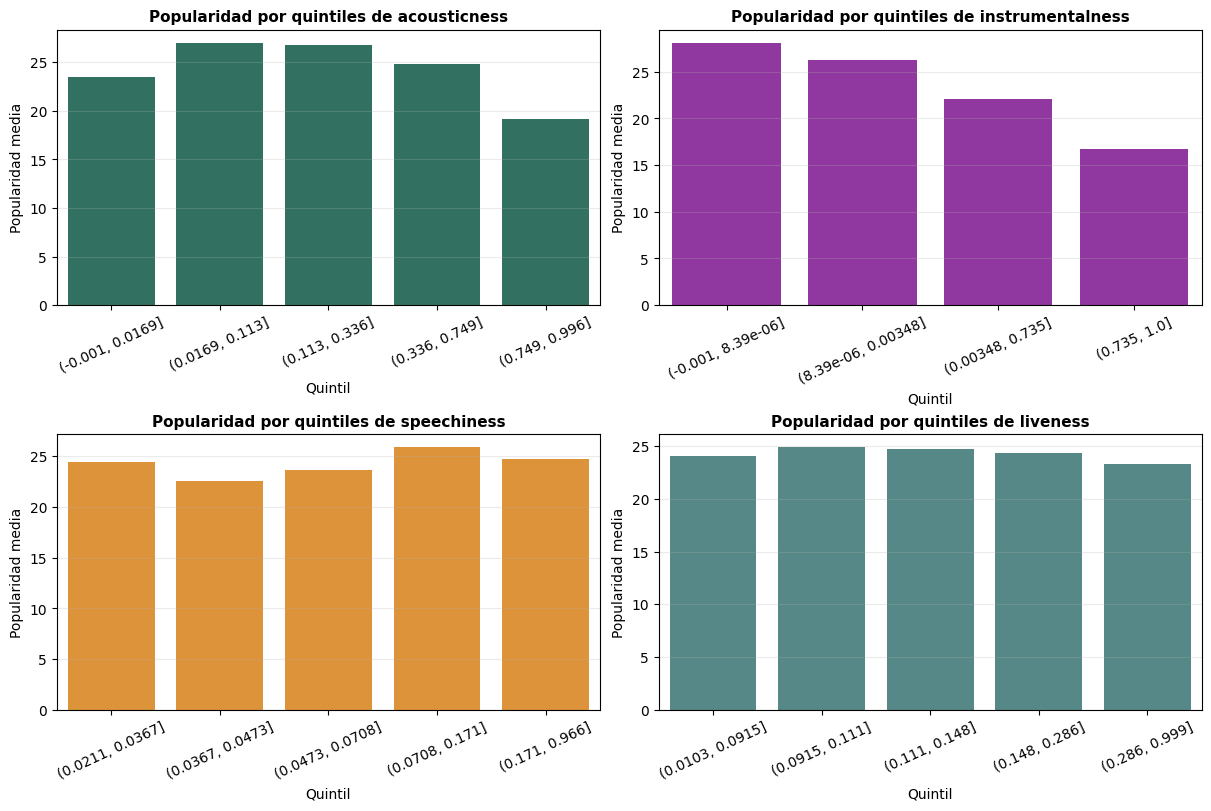

In [30]:
texture_pop_df = texture_df.copy()

for col in ["acousticness", "instrumentalness", "speechiness", "liveness"]:
    # qcut puede reducir el número de bins cuando hay muchos empates.
    texture_pop_df[f"{col}_q"] = pd.qcut(texture_pop_df[col], q=5, duplicates="drop")

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for ax, col, color in zip(
    axes.flat,
    ["acousticness", "instrumentalness", "speechiness", "liveness"],
    ["#277C68", "#9C27B0", "#F8961E", "#4D908E"]
):
    summary = texture_pop_df.groupby(f"{col}_q", observed=False)["popularity"].mean().reset_index()
    sns.barplot(data=summary, x=f"{col}_q", y="popularity", color=color, ax=ax)
    ax.set_title(f"Popularidad por quintiles de {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Quintil")
    ax.set_ylabel("Popularidad media")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)

plt.show()

## 4. Gráfico con plotly

In [31]:
import plotly.express as px
import plotly.graph_objects as go

In [32]:
num_cols = spotify_df.select_dtypes(include="number").columns.tolist()

pearson = spotify_df[num_cols].corr(method="pearson")
spearman = spotify_df[num_cols].corr(method="spearman")

pps_long = pps.matrix(spotify_df[num_cols])[["x", "y", "ppscore"]]
pps_mat = (
    pps_long
    .pivot(index="y", columns="x", values="ppscore")
    .reindex(index=num_cols, columns=num_cols)
    .fillna(0)
)

corr_dict = {
    "Pearson": pearson,
    "Spearman": spearman,
    "PPS": pps_mat,
}

fig = go.Figure()

for i, (name, mat) in enumerate(corr_dict.items()):
    fig.add_trace(
        go.Heatmap(
            z=mat.values,
            x=mat.columns,
            y=mat.index,
            colorscale="RdBu" if name != "PPS" else "YlGnBu",
            zmin=-1 if name != "PPS" else 0,
            zmax=1,
            visible=(i == 0),
            hovertemplate="X: %{x}<br>Y: %{y}<br>Valor: %{z:.3f}<extra></extra>",
            colorbar=dict(
                title=name,
                x=1.02,
                len=0.88,
                y=0.5,
            ),
        )
    )

buttons = []
for i, name in enumerate(corr_dict.keys()):
    vis = [False] * len(corr_dict)
    vis[i] = True
    buttons.append(
        dict(
            label=name,
            method="update",
            args=[
                {"visible": vis},
                {"title": f"Matriz interactiva - {name}"},
            ],
        )
    )

fig.update_layout(
    title="Matriz interactiva - Pearson",
    width=700,
    height=600,
    autosize=False,
    margin=dict(t=120, r=120, b=60, l=80),
    xaxis_tickangle=-45,
    updatemenus=[
        dict(
            type="dropdown",
            x=1.0,
            y=1.18,
            xanchor="right",
            yanchor="top",
            buttons=buttons,
            bgcolor="white",
        )
    ],
)

fig.show()

In [33]:
sankey_df = spotify_df[["mode", "key", "popularity"]].dropna().copy()
sankey_df = sankey_df[sankey_df["key"].between(0, 11)]

sankey_df["mode_label"] = sankey_df["mode"].map({0: "Minor", 1: "Major"})
sankey_df["key_label"] = sankey_df["key"].map(key_map)
sankey_df["popularity_norm"] = (sankey_df["popularity"] / 100).clip(0, 1)

bins = np.linspace(0, 1, 11)
range_labels = [f"{i/10:.1f}-{(i+1)/10:.1f}" for i in range(10)]

sankey_df["popularity_norm_adj"] = np.where(
    sankey_df["popularity_norm"] == 1,
    np.nextafter(1.0, 0.0),
    sankey_df["popularity_norm"],
)

sankey_df["pop_bin"] = pd.cut(
    sankey_df["popularity_norm_adj"],
    bins=bins,
    labels=range_labels,
    include_lowest=True,
    right=False,
).astype(str)

mode_nodes = ["Major", "Minor"]
key_nodes = [key_map[k] for k in range(12)]
pop_nodes = range_labels

all_nodes = mode_nodes + key_nodes + pop_nodes
node_idx = {name: i for i, name in enumerate(all_nodes)}

flow_mk = (
    sankey_df
    .groupby(["mode_label", "key_label"], observed=False)
    .size()
    .reset_index(name="value")
)

flow_kp = (
    sankey_df
    .groupby(["key_label", "pop_bin"], observed=False)
    .size()
    .reset_index(name="value")
)

sources = [node_idx[r["mode_label"]] for _, r in flow_mk.iterrows()] + [node_idx[r["key_label"]] for _, r in flow_kp.iterrows()]
targets = [node_idx[r["key_label"]] for _, r in flow_mk.iterrows()] + [node_idx[r["pop_bin"]] for _, r in flow_kp.iterrows()]
values = flow_mk["value"].tolist() + flow_kp["value"].tolist()

mode_colors = {"Major": "#F58518", "Minor": "#4C78A8"}
key_color = "#9AA0A6"

pop_palette = px.colors.sequential.OrRd
pop_colors = {
    label: pop_palette[min(i + 2, len(pop_palette) - 1)]
    for i, label in enumerate(pop_nodes)
}

node_colors = [
    mode_colors.get(n, key_color) if n in mode_nodes
    else (pop_colors.get(n, key_color) if n in pop_nodes else key_color)
    for n in all_nodes
]

link_colors = []
for _ in flow_mk.itertuples(index=False):
    link_colors.append("rgba(120,120,120,0.35)")
for _, r in flow_kp.iterrows():
    if r["pop_bin"] in ["0.8-0.9", "0.9-1.0"]:
        link_colors.append("rgba(179,0,0,0.45)")
    else:
        link_colors.append("rgba(120,120,120,0.25)")

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=18,
                thickness=16,
                line=dict(color="black", width=0.3),
                label=all_nodes,
                color=node_colors,
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors,
                hovertemplate="Flujo: %{source.label} -> %{target.label}<br>Canciones: %{value}<extra></extra>",
            ),
        )
    ]
)

fig.update_layout(
    title="Sankey de flujo musical: Modo -> Tonalidad -> tramo de popularidad normalizada",
    width=900,
    height=500,
    font=dict(size=12),
)

fig.show()